Sveučilište u Zagrebu<br/>
Fakultet elektrotehnike i računarstva<br/>
Zavod za elektroničke sustave i obradbu informacija

Akademska školska godina 2025./2026.

**1. vježba: Rastav signala**

*Osnove obradbe signala* (183447, 223374)

Autor: Tomislav Petković

Datum: 2025-10-14

Molimo vas da komentare na ove upute (ispravke, primjedbe, prijedloge itd.) šaljete e-poštom na tomislav.petkovic.jr@fer.unizg.hr.

© Sveučilište u Zagrebu Fakultet elektrotehnike i računarstva, 2025.

Umnažanje i distribucija ovih uputa su dozvoljeni samo ako svaka kopija sadrži gorenavedenu informaciju o autorskim pravima te ovu dozvolu o umnažanju.

# Uvod

Upute za prvu laboratorijsku vježbu iz predmeta *Osnove obradbe signala* su pripremljene u obliku <a href="https://jupyter.org/">Jupyterske</a> bilježnice.

Jupyterska bilježnica koristi <a href="https://ipython.org/">IPython</a> koji je interaktivni interpreter za Pyhton. Uobičajeni način korištenja bilježnice je kroz internetski preglednik. Pri tome preglednik može biti spojen na lokalnu bilježnicu, no isto tako se mogu koristiti udaljene bilježnice koje se izvršavaju na Googleovom Colaboratoryu.

Svi zadaci u ovoj bilježnici su dovoljno jednostavni tako da se mogu riješiti korištenjem <a href="https://colab.research.google.com">Googleovog Colaboratorya</a> (skraćeno Colab).

Svaki softver je samo alat. Sukaldno tome, osim Pythona slobodno smijete koristiti i druge alate kao što su <a href="https://www.mathworks.com/products/matlab.html">Matlab</a>, <a href="https://www.gnu.org/software/octave/index">GNU Octave</a> i <a href="https://www.scilab.org/">Scilab</a> kako bi riješili zadane zadatke. Napominjemo da korištenje drugih alata može značiti da vaš izvještaj s vježbe ne možete predati popunjavanjem ove bilježnice, odnosno da morate pripremiti novi pisani izvještaj, pogotovo ako koristite softver koji se ne može povezati s Jupyterskom bilježnicom. Dodatno, nastavnici vam mogu pomoći oko izrade vježbe samo ako koristite Python ili Matlab.

## Preporučeno čitanje

Ako do sada niste koristili Python onda započnite s bilo kojim od kratkih uvoda za početnike kao što je npr. službeni tutorial dostupan na adresi <a href="https://docs.python.org/3/tutorial/">https://docs.python.org/3/tutorial/</a>.

Studentima dobro upoznatim s Matlabom koji su početnici u Pythonu se toplo preporuča da pročitaju dokument <a href="https://numpy.org/doc/stable/user/numpy-for-matlab-users.html">NumPy for Matlab users</a> prije rješavanja ove laboratorijske vježbe.

## Upute za predaju izvještaja s vježbe

Ako rješavate vježbu u Pythonu onda jednostavno upišite vaše odgovore u prazna polja, i to programski kod u polja za kod te odgovore na postavljena pitanja u tekstualna polja.

Prazna polja u koja upisujete programski kod sadrže zadani komentar: `# Upišite vaše rješenje`.

Tekstualna polja u koja morate upisati odgovore na postavljena pitanja sadrže masni tekst napisan velikim tiskanim slovima: **UPIŠITE VAŠ ODGOVOR**.

Jednom kada su svi zadaci riješeni ispunjenu bilježnicu pohranite u datoteku s imenom `JMBAG_IME_PREZIME_Vjezba_1.ipynb` te tu datoteku predajte pod odgovarajuću zadaću u FER-ovom Moodleu.

Predane bilježnice mogu biti automatski re-evaluirane što odgovara naredbi  *Restart Kernel and Run All Cells*. Prema tome, svakako prije predaje vaše bilježnice pokrenite tu naredbu i provjerite ispravnost svih unesenih rješenja.

Ako ste vježbu izradili korištenjem nekog drugog softvera koji nije kompatibilan s Jupyterskom bilježnicom onda morate pripremiti standardni pisani izvještaj s laboratorijske vježbe.

# Podaci o studentu

Molimo vas da prije ispunjavanja ostatka bilježnice dvaput kliknete na ovaj tekst te zatim upište vaše podatke:

Ime: **FRAN GALIĆ**

Matični broj (JMBAG): **0036546889**

Također odmah promijenite ime datoteke u JMBAG_IME_PREZIME_Vjezba_1.ipynb.

# Uvoz potrebnih funkcija

Radi smanjivanja razlika između programskog koda u Pythonu i u Matlabu u ovoj bilježnici ćemo namjerno uvesti sve potrebne funkcije iz <a href="https://www.scipy.org/">SciPy</a>-ja, <a href="https://numpy.org/">NumPy</a>-ja i <a href="https://matplotlib.org/">Matplotlib</a>-a izravno u globalni imenik tako da možemo jednostavno koristiti `fft` umjesto punog imena `scipy.fft.fft`.

Imajte u vidu da je ovakav pristup uvjetno prihvatljiv radi pojednostavljenja koda za laboratorijske vježbe jer su rizici kolizije i neočekivanih nuspojava za kratki kod kojeg trebate pripremiti u zadanim zadacima minimalni, no svakako ga je najbolje izbjegavati u praksi. **Uvoz funkcija u globalni imenik se ne koristi u produkcijskom kodu.**

Ako preferirate korištenje imenika i punih imena funkcija onda slobodno izmijenite naredbe za uvoz funkcija tako da sve uvezene funkcije ostanu strogo razdvojene.

In [1]:
# Uvezi potrebne funkcije u globalni imenik
# numpy mora biti učitan prvi tako da njegove funkcije ne prikriju funkcije iz scipy.signal i scipy.fft
import math
from numpy import *
from scipy.signal import *
from scipy.fft import *
from matplotlib.pyplot import *

# 1. Vremenski diskretni signali konačnog trajanja

U ovoj laboratorijskoj vježbi istražujemo kako se računala koriste za numeričku analizu signala. Radi jednostavnosti koristitimo isključivo sintetičke signale. Kada generiramo sitnetički signal u NumPyju ili u Matlabu obično započinjemo s geneiranjem niza (vektora) koji sadrži vremenske korake, i to korištenjem naredbe [`numpy.arange`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) u Pyhtonu ili korištenjem Matlabovog operatora [`:`](https://www.mathworks.com/help/matlab/ref/colon.html). Jednom kada smo generiraili niz odabranih vremenskih koraka na njih možemo primijeniti bilo koju funkciju radi računanja vrijednosti sintetičkog signala.

Imajte u vidu da za geneiranje vremenskih koraka koje koristimo za daljnje numeričko računanje svakako želimo generirati brojeve u dvostrukoj preciznosti. Takvo ponašanje je predodređeno u Matlabu, odnosno Matlabova naredba `0:1:99` generira niz brojeva od 0 do 99 s korakom 1 koji su uvijek spremljeni u dvostrukoj preciznosti. Isti niz u Pythonu generiramo s `numpy.arange(0, 100, 1)`, no ta naredba će gotovo sigurno generirati niz tipa `int64` pa zato uvijek koristite `numpy.arange(0.0, 100.0, 1.0)` (primijetite decimalnu točku). Uočite da `arange` za razliku od Matlabove `:` ne uključuje gornju granicu intervala u generirani interval. Također uočite drugačiji redoslijed argumenata: u Matlabu je korak zadan u sredini između početne i konačne vrijednosti dok je u Pythonu zadan kao zadnji argument.

## 1.A Generiranje vremenski diskretnih signala

Napišite funkcije koje za zadane ulazne vrijednosti koraka $n$ računaju vrijednosti uzoraka za sljedeća tri vremenski diskretna signala:

$$\begin{align}
d_k[n]&=\delta[n-k]\\
c_k[n]&=\cos\Bigl(\frac{(2n+1)k\pi}{2N}\Bigr)\\
e_k[n]&=\exp\Bigl(j\frac{2\pi}{N}nk\Bigr)\\
\end{align}$$

Pri tome je vremenski korak $n$ obavezna ulazna vrijednost koja se predaje kao niz brojeva, $k$ je parametar koji definira signal s pretpostavljenom vrijednošću jednakom nuli, a $N$ je ciljani broj uzoraka signala konačnog trajanja s pretpostavljenom vrijednošću 10.

Neka imena funkcija budu `oos_d_k`, `oos_c_k` i `oos_e_k` i neka njihova deklaracija bude oblika:

```
def oos_x_x(n, k = 0, N = 10):
  # ovdje dolazi programski kod za računanje izlaznih vrijednosti iz ulaza n koje spremate u x
  return x
```

Napomena: Prvih nekoliko pitanja u ovoj bilježnici već imaju djelomično upisano rješenje. To djelomično upisano rješenje jest tu da pomogne onima koji prvi put koriste Python. Također, dozvoljeno je već upisano rješenje predati kao svoje, odnosno nije potrebno pisati nova rješenja.

In [2]:
# Jedno moguće rješenje
def oos_d_k(n, k = 0, N = 10):
    x = zeros_like(n, dtype=float)
    for i in range(len(n)):
        if k == n[i]:
            x[i] = 1.0
    return x

def oos_e_k(n, k = 0, N = 10):
    x = zeros_like(n, dtype=complex)
    for i in range(len(n)):
        x[i] = exp(2.0*1j*math.pi*n[i]*k/N)
    return x

# Upišite vaše rješenje


## 1.B Crtanje vremenski diskretnih signala

Vremenski diskretne signale možemo crtati korištenjem `stem` ili `plot` naredbe. Naredba `stem` je prikladna za crtanje vremenski diskretnih signala s manjim brojem uzoraka jer svaki uzorak predstavlja pomoću vertikalne linije čija visina odgovara vrijednosti uzorka. Naredba `plot` je pak prikladna za crtanje vremenski diskretnih signala s velikim brojem uzoraka jer spaja vrijednosti uzoraka ravnim linijama čime se postiže privid kontinuiranosti signala.

Uzastopno korištenje `stem` ili `plot` naredbi jednostavno dodaje grafove signala u istu sliku što u slučaju crtanja više signala čini slike prenatrpanima pa se za razdvajanje nacrtanih signale koristi funkcija `figure` koja otvara novu sliku. Ako crtamo više slika onda svaku sliku želimo jasno označiti za što koristimo naredbu `title` kojom dodajemo naziv. Osim toga osi slike možemo označiti korištenjem naredbi `xlabel` i `ylabel`.

Napišite dvije funkcije za crtanje vremenski diskretnog signala u novoj jasno označenoj slici koje se zovu `oos_stem` i `oos_plot` s deklaracijom oblika:

```
def oos_xxxx(x, ime=''):
  # ovdje dolazi programski kod za otvaranje i imenovanje slike te crtanje signala x
```

Napomena: Puna imena naredbi `plot`, `stem`, `figure`, `title`, `xlabel` i `ylabel` u Pythonu su
[`matplotlib.pyplot.plot`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html),
[`matplotlib.pyplot.stem`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.stem.html),
[`matplotlib.pyplot.figure`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.figure.html),
[`matplotlib.pyplot.title`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.title.html),
[`matplotlib.pyplot.xlabel`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.xlabel.html) i
[`matplotlib.pyplot.ylabel`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.ylabel.html).
Te naredbe su jako slične Matlabovim
[`stem`](https://www.mathworks.com/help/matlab/ref/stem.html),
[`plot`](https://www.mathworks.com/help/matlab/ref/plot.html),
[`figure`](https://www.mathworks.com/help/matlab/ref/figure.html),
[`title`](https://www.mathworks.com/help/matlab/ref/title.html),
[`xlabel`](https://www.mathworks.com/help/matlab/ref/xlabel.html) i
[`ylabel`](https://www.mathworks.com/help/matlab/ref/ylabel.html)
naredbama.

In [3]:
# Jedno moguće rješenje koje vrijedi samo za realne signale
def oos_stem(x, ime=''):
  figure()
  stem(x)
  title(ime)

# Upišite vaše rješenje


Korištenjem pripremljenih funkcija za generiranje signala `oos_d_k`, `oos_c_k` i `oos_e_k` te funkcija `oos_stem` i `oos_plot` za crtanje signala generirajte i zatim nacrtajte svaki od signala $d_k[n]$, $c_k[n]$ i $e_k[n]$ za $k=2$ uz $N_1=10$ i $N_2=1000$, dakle ukupno crtate šest signala.

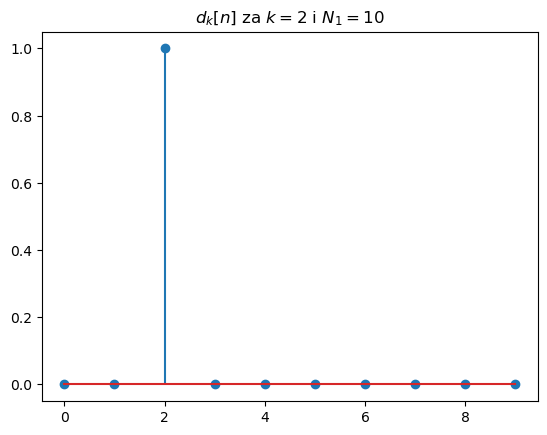

In [4]:
# Jedno moguće rješenje
n = arange(0.0, 10.0, 1.0);
oos_stem(oos_d_k(n, 2), '$d_k[n]$ za $k=2$ i $N_1=10$')

# Upišite vaše rješenje


# 2. Skalarni umnožak, ortogonalnost i Gramova matrica

Ako su $x[n]$ i $y[n]$ dva vremenski diskretna signala konačnog tranja od $N$ uzoraka onda njihov skalarni umnožak možemo definirati kao

$$\langle x[n],y[n]\rangle=\sum_{n=0}^{N-1}x[n]y^*[n].$$

Napomena: Kod definicije skalarnog umnoška možemo prebaciti operaciju kompleksne konjugacije na prvi član umnoška, odnosno neke definicije u zbroju koriste $x^*[n]y[n]$ umjesto $x[n]y^*[n]$. Za razlikovanje ta dva slučaja se može koristiti različita notacija:

$$\begin{align}
\bigl\langle\, x[n]\,,\,y[n]\,\bigr\rangle&=\sum\nolimits_{n=0}^{N-1}x[n]y^*[n]\\
\bigl\langle\, x[n]\,\bigm|\,y[n]\,\bigr\rangle&=\sum\nolimits_{n=0}^{N-1}x^*[n]y[n]\\
\end{align}$$

Napišite funkciju za računanje skalaranog umnoška `oos_dot` s deklaracijom oblika:

```
def oos_dot(x, y):
  # ovdje dolazi programski kod za računanje skalarnog umnoška
```

Napomena: U NumPyju postoji više funkcija koje se mogu koristiti za računanje skalarnog i unutrašnjeg umnoška,
[`numpy.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html),
[`numpy.vdot`](https://numpy.org/doc/stable/reference/generated/numpy.vdot.html),
[`numpy.vecdot`](https://numpy.org/doc/stable/reference/generated/numpy.vecdot.html) i
[`numpy.inner`](https://numpy.org/doc/stable/reference/generated/numpy.inner.html). Od njih su
[`numpy.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) i
[`numpy.inner`](https://numpy.org/doc/stable/reference/generated/numpy.inner.html)  prilagođeni za realne signale, a
[`numpy.vdot`](https://numpy.org/doc/stable/reference/generated/numpy.vdot.html) i
[`numpy.vecdot`](https://numpy.org/doc/stable/reference/generated/numpy.vecdot.html)
za kompleksne signale. U Matlabu se koristi isključivo naredba
[`dot`](https://www.mathworks.com/help/matlab/ref/dot.html). Većina naredbi u modernim programskim jezicima za računanje skalarnog umnoška nad kompleksnim vektorima koristi definiciju gdje je operacija kompleksne konjugacije na prvom član umnoška.

In [5]:
# Upišite vaše rješenje


## 2.A Ortogonalnost

Dva vremenski diskretna signala $x[n]$ i $y[n]$ su ortogonalna ili okomita ako je njihov skalarni umnožak jednak nuli, odnosno

$$\langle x[n],y[n]\rangle=\sum_{n=0}^{N-1}x[n]y^*[n]=0$$

Ispitajte ortogonalnost signala $d_k[n]$, $c_k[n]$ i $e_k[n]$ koje generiramo pripremljenim funkcijama `oos_d_k`, `oos_c_k` i `oos_e_k` za dva različita indeksa baznog vektora $k_1=2$ i $k_2=3$ za duljinu $N=10$, i to prvo za $n=0,1,\ldots,N-1$ (interval $[0,N-1]$), a zatim za $n=0,1,\ldots,N+3$ (interval $[0,N+3])$.

Napomena: Skalarni produkt računamo numerički pa u slučaju okomitosti vrijednost skalarnog umnoška neće biti točno jednaka nuli nego će biti jako blizu nule. Shodno tome za automatsko ispitivanje ortogonalnosti skalarnog ne možemo koristiti test stroge jednakosti vrijednosti skalranog umnoška s nulom nego moramo definirati dozvoljenu toleranciju odstupanja od nule $\epsilon$ te zatim provjeriti vrijedi li $\bigl|\langle x,y\rangle\bigr|<\epsilon$. Za takvo testiranje možemo koristiti funkciju
[`math.isclose`](https://docs.python.org/3/library/math.html#math.isclose) ili
[`numpy.isclose`](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html). Za više detalja o problemima računanja s pomičnom točkom pogledajte dokumente https://docs.python.org/3/tutorial/floatingpoint.html i 
[What Every Computer Scientist Should Know About Floating-Point Arithmetic?](https://docs.oracle.com/cd/E19957-01/806-3568/ncg_goldberg.html).

In [6]:
# Upišite vaše rješenje


Jesu li parovi $d_{k_1}[n]$ i $d_{k_2}[n]$, $c_{k_1}[n]$ i $c_{k_1}[n]$, te $e_{k_1}[n]$ i $e_{k_2}[n]$ ortogonalni za $n=0,1,\ldots,N-1$ (interval $[0,N-1]$)?

**UPIŠITE VAŠ ODGOVOR**


Jesu li parovi $d_{k_1}[n]$ i $d_{k_2}[n]$, $c_{k_1}[n]$ i $c_{k_1}[n]$, te $e_{k_1}[n]$ i $e_{k_2}[n]$ ortogonalni za $n=0,1,\ldots,N+3$ (interval $[0,N+3])$? Objasnite!

**UPIŠITE VAŠ ODGOVOR**


## 2.B Matrica baznih signala

Ako razmatramo $N$ dimenzionalni vektorski prostor onda u njemu možemo definirati $N$ baznih signala koji razapinju taj prostor. Radi jednostavnijeg daljnjeg račnunjanja sve te bazne signale možemo posložiti u matricu $\Phi$ koja ih sadrži u svojim stupcima.

Napišite funkciju za slaganje matrice baznih signala koja se zove `oos_phi` i koja kao ulazne parametre prima odgovarajuću funkciju iz zadatka 1.A koja generira bazni signal te dimenziju prostora $N$:

```
def oos_phi(baza, N):
  # ovdje dolazi programski kod za slaganje matrice baznih funkcija
```

Zatim korištenjem pripremljene funkcije `oos_phi` za $N=4$ (prostor signala od četiri uzorka) definirajte matrice baznih funkcija `Phi_d`, `Phi_c` i `Phi_e` te ispišite njihove vrijednosti za tri skupine signala iz zadatka 1.A, odnosno za:
1. pomaknute jedinične impulse $d_k[n]$ koje generiramo funkcijom `oos_d_k` (vremenska baza),
2. kosinusoide $c_k[n]$ koje generiramo funkcijom `oos_c_k` (diskretna kosinusna baza), i
3. kompleksne eksponencijale $e_k[n]$ koje generiramo funkcijom `oos_d_k` (diskretna Fourierova baza).

In [7]:
# Jedno moguće rješenje
def oos_phi(baza, N):
    Phi = zeros((N,N), dtype=complex);
    for k in range(N):
        val = baza(arange(0.0, N, 1.0), k, N)
        for n in range(N):            
            Phi[n,k] = val[n]
    return matrix(Phi)

Phi_e = oos_phi(oos_e_k, 4)
print(Phi_e)

# Upišite vaše rješenje


[[ 1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j
   1.0000000e+00+0.0000000e+00j  1.0000000e+00+0.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j  6.1232340e-17+1.0000000e+00j
  -1.0000000e+00+1.2246468e-16j -1.8369702e-16-1.0000000e+00j]
 [ 1.0000000e+00+0.0000000e+00j -1.0000000e+00+1.2246468e-16j
   1.0000000e+00-2.4492936e-16j -1.0000000e+00+3.6739404e-16j]
 [ 1.0000000e+00+0.0000000e+00j -1.8369702e-16-1.0000000e+00j
  -1.0000000e+00+3.6739404e-16j  5.5109106e-16+1.0000000e+00j]]


## 2.C Gramova matrica

U definiciji skalarnog umnoška signala $x[n]$ i $y[n]$ operaciju konjugiranja kompleksnog broja možemo staviti na prvi ili na drugi član skalarnog umnoška što može biti izvor zabune, no ako se pređe na matričnu notaciju ta nedoređenost nestaje. Ako signale $x[n]$ i $y[n]$ predstavimo kao vektor-stupce onda za skalarne umnoške vrijedi (jer transponiranje umnoška ne mijenja položaj operacije konjugiranja)

$$\langle x[n],y[n]\rangle=\sum_{n=0}^{N-1}x[n]y^*[n]=\mathbf{y}^H\mathbf{x}=\mathbf{x}^T\mathbf{y}^*$$

i

$$\langle x[n]|y[n]\rangle=\sum_{n=0}^{N-1}x^*[n]y[n]=\mathbf{x}^H\mathbf{y}=\mathbf{y}^T\mathbf{x}^*$$

Napomena: Operacija $\mathbf{A}^H$ nad matricom ili vektorom $\mathbf{A}$ se zove Hermitsko ili konjugirano transponiranje i u Numpyju se može koristiti
[`numpy.matrix.H`](https://numpy.org/doc/stable/reference/generated/numpy.matrix.H.html), a u Matlabu operator
[`'`](https://www.mathworks.com/help/matlab/ref/double.ctranspose.html).

Gramova matrica $\mathbf{G}$ se definira kao matrica svih skalarnih umnožaka nekog skupa baznih signala.

Ako je $\mathbf{\Phi}$ matrica koja sadrži sve bazne signale u svojim stupcima onda Gramovu matricu definiramo kao umnožak

$$\mathbf{G}=\mathbf{\Phi}^H\mathbf{\Phi}$$

Iz tri matrice baznih funkcija `Phi_d`, `Phi_c` i `Phi_e` izračunate u prethodnom zadatku za $N=4$ (prostor signala od četiri uzorka) izračunajte i ispišite tri Gramove matrice `Gram_d`, `Gram_c` i `Gram_e` za tri skupine signala iz zadatka 1.A (vremenska baza, diskretna kosinusna baza, i diskretna Fourierova baza).

In [8]:
# Upišite vaše rješenje


Koje baze su ortogonalne, a koje nisu? Ukratko objasnite!

**UPIŠITE VAŠ ODGOVOR**


Je li ijedna od tri baze ortonormalna? Ako jest, navedite koje su to baze, a ako nema takvih baza onda navedite definiciju ortonormalne baze!

**UPIŠITE VAŠ ODGOVOR**


# 3. Transformacija i rekonstrukcija signala

Vremenski diskretni signal $x[n]$ konačnog trajanja ili duljine $N$ možemo predstaviti kao kombinaciju $N$ baznih signala $\phi_k[n]$, $k=0,1,\ldots,N-1$, odnosno vrijedi

$$x[n]=\sum_{k=0}^{N-1}s[k]\phi_k[n],$$

gdje je $s[k]$ spektar koji definira doprinos svake bazne funkcije $\phi_k[n]$.

U matričnom obliku gdje su $x[n]$ i $s[k]$ predstavljeni kao vektor-stupci izraz za rekonstrukciju signala iz spektra postaje

$$\mathbf{x}=\mathbf{\Phi}\mathbf{s},$$

a spektar $\mathbf{s}$ kojeg nazivamo i transformacijom signala se računa kao

$$\mathbf{s}=\mathbf{T}\mathbf{x}=\mathbf{G}^{-1}\mathbf{\Phi}^H\mathbf{x}=\bigl(\mathbf{\Phi}^H\mathbf{\Phi}\bigr)^{-1}\mathbf{\Phi}^H\mathbf{x},$$

gdje je $\mathbf{T}=\bigl(\mathbf{\Phi}^H\mathbf{\Phi}\bigr)^{-1}\mathbf{\Phi}^H$ transformacijska matrica koju računamo kao (lijevu) pseudoinverznu matricu matrice baznih funkcija $\mathbf{\Phi}$.

Prva napomena: U slučaju kada bazne funkcije $\phi_k[n]$ u potpunosti razapinju $N$-dimenzionalni prostor vrijedi $$\mathbf{T}=\bigl(\mathbf{\Phi}^{H}\mathbf{\Phi}\bigr)^{-1}\mathbf{\Phi}^{H}=\mathbf{\Phi}^{-1},$$
odnosno postoji inverz matrice $\mathbf{\Phi}$ koji je jednak lijevoj pseudoinverznoj matrici. No u praski se često koristi slučaj u kojem je broj baznih vektora $K$ značajno manji od dimenzije prostora $N$ tako da rastav signala nužno ima neku grešku $e[n]$ te vrijedi

$$x[n]=e[n]+\sum\nolimits_{k=0}^{K-1}s[k]\phi_k[n]$$

U tom slučaju matrica $\mathbf{\Phi}$ nije kvadratna već je dimenzija $N\times K$, odnosno ima $N$ redaka i $K$ stupaca, pa nije invertibilna. Tada se koristi transformacijska matrica $\mathbf{T}$ koja je izračunata kao (lijevi) pseudoinverz od $\mathbf{\Phi}$ i koja ima svojstvo da je izračunati spektar $s[k]$ minimizira srednju kvadratnu grešku, odnosno vrijednost

$$\bigl|\bigl|e[n]\bigr|\bigr|_2=\Bigl|\Bigl|x[n]-\sum\nolimits_{k=0}^{K-1}s[k]\phi_k[n]\Bigr|\Bigr|_2$$

je najmanja moguća.

Druga napomena: Za računanje transformacijske matrice može se koristiti definicijski izraz, no može se koristiti i funkcija za računanje pseudoinverzne matrice, i to
[`numpy.linalg.pinv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html) u Pythonu i
[`pinv`](https://www.mathworks.com/help/matlab/ref/pinv.html) u Matlabu.

## 3.A Transformacijske matrice

Iz tri matrice baznih funkcija `Phi_d`, `Phi_c` i `Phi_e` izračunate u prethodnom dijelu vježbe za $N=4$ (prostor signala od četiri uzorka) izračunajte i ispišite tri transformacijske matrice `T_d`, `T_c` i `T_e` za tri skupine signala iz zadatka 1.A (vremenska baza, diskretna kosinusna baza, i diskretna Fourierova baza).

In [9]:
# Upišite vaše rješenje


## 3.B Transformacija jednog signala

Korištenjem tri transformacijske matrice `T_d`, `T_c` i `T_e` iz prethodnog zadatka izračunajte tri transformacije odnosno tri spektra istog signala

$$x[n]=\{\underline{1},2,3,4\}$$

korištenjem izraza $\mathbf{s}=\mathbf{T}\mathbf{x}$ te ispišite tri dobivena spektra `s_d`, `s_c` i `s_e`.

Zatim iz tri dobivena spektra `s_d`, `s_c` i `s_e` korištenjem izraza $\mathbf{\hat x}=\mathbf{\Phi}\mathbf{s}$ izračunajte rekonstrukcije polaznog signala te pripadnu grešku rekonstrukcije $\mathbf{x}-\mathbf{\hat x}$ za koju očekujemo da mora išćezavati odnosno, biti jako blizu nuli.

Napomena: Slično kao kod testiranja ortogonalnosti ako numerički računamo spektar pa iz spektra numerički rekonstruiramo signal onda će se tako rekonsturirani signal $\mathbf{\hat x}$ gotovo uvijek neznatno razlikovati od početnog signala $\mathbf{\hat x}$. Zato opet moramo definirati dozvoljenu toleranciju odstupanja između dva signala $\epsilon$ te zatim provjeriti vrijedi li
$$\max\bigl|\mathbf{x}-\mathbf{\hat x}|=\max\bigl|\mathbf{x}-\mathbf{\Phi}\mathbf{s}|<\epsilon.$$
Za takvo testiranje može se koristiti funkcija [`numpy.allclose`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html).

In [10]:
# Upišite vaše rješenje


Je li polazni signal uspješno rekonstruiran i je li greška rekonstrukcije unutar očekivane tolerancije? Ukratko objasnite!

**UPIŠITE VAŠ ODGOVOR**

## 3.C Transformacija baznog signala u vlastitoj i drugoj bazi

Korištenjem tri transformacijske matrice `T_d`, `T_c` i `T_e` za $N=4$ (prostor signala od četiri uzorka) izračunajte tri spektra ili transformacije svake od tri bazne funkcije $d_2[n]$, $c_2[n]$ i $e_2[n]$ (dakle, $k=2$).

In [11]:
# Upišite vaše rješenje


U kojem slučaju je dobiveni spektar rijedak (jednak nuli svugdje osim za jedan $k$), a u kojem nije (gotovo sve vrijednosti spektra su različite od nule)? Ukratko objasnite!

**UPIŠITE VAŠ ODGOVOR**

# 4. Odabir baznih vektora (neobavezno)

**Ovaj dio vježbe nije obavezan; riješite ga ako želite znati više.**

U dosadašnjim zadacima smo razmatrali problem računanja spektra ili transformacije signala u slučaju poznatih baznih funkcija, a u ovom zadatku ćemo razmotriti kako možemo izabrati dobre bazne funkcije. Primjetite da je odabir baznih funkcija neraskidivo vezan sa signalima koje razmatramo, odnosno ako ništa ne znamo o signalima koje razmatramo onda ne možemo odabrati dobre bazne funkcije.

Kako je vizualizacija odabira jednostavna za dvodimenzionalni prostor jer sve možemo nacrtati u ravnini, u ovom zadatku se ograničavamo na signale konačnog trajanja od dva uzorka, dakle $N=2$.

Dodatno, uvodimo ograničenje na moguće signale kojim ćemo definirati signal kao slučajni vektor izvučen iz multivarijantne (bivarijantne) normalne raspodjele.

## 4.A Generiranje i vizualizacija slučajnih signala

Kod računalnih eksperimenata sa slučajno generiranim signalima odnosno brojevima često želimo osigurati ponovljivost generiranih signala što se postiže inicijalizacijom korištenog generatora pseudoslučajnih brojeva u neku poznatu početnu vrijednost.

Ako koristimo Numpy onda se koristi
[`numpy.random.default_rng`](https://numpy.org/doc/stable/reference/random/generator.html) za stvaranje i inicijalizaciju generatora slučajnih brojeva, te se zatim koristi odgovarajuća metoda za izvlačenje uzoraka koji odgovaraju odabranoj distribuciji. Za izvlačenje uzoraka signala iz bivarijantne normalne razdiobe se koristi metoda
[`numpy.random.Generator.multivariate_normal`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multivariate_normal.html#numpy.random.Generator.multivariate_normal) kojoj zadajemo očekivanu vrijednost, korelacijsku matricu te broj uzoraka koje želimo generirati.

Generirajte 10000 realizacija (uzoraka) slučajnog signala $x[n]$ konačnog trajanja od dva uzorka gdje je svaka realizacija signala izvučena iz bivarijantne normalne razdiobe s očekivanjem nula i korelacijskom matricom

$$\mathbf{\Sigma}=\begin{bmatrix}1.3&0.5\\0.5&0.7\end{bmatrix}$$

[[-0.38605673 -0.22226587]
 [ 1.30628044 -0.94959146]
 [-0.31551206  0.50946067]
 ...
 [ 1.01076814  1.09409001]
 [ 0.45373393  0.34556249]
 [-1.16211011  0.05783131]]


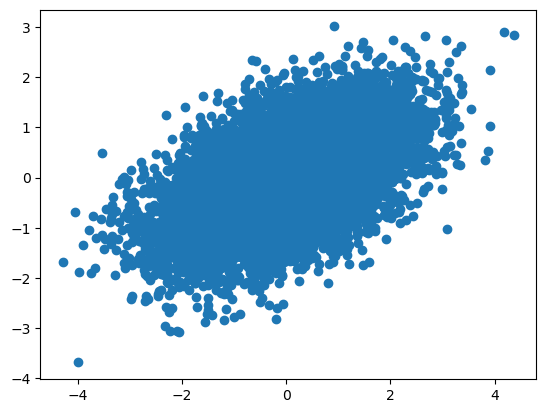

In [12]:
# Jedno moguće rješenje

# Stvaramo i inicijaliziramo generator slučajnih brojeva s poznatom početnom vrijednošću 25 radi ponovljivosti
rng = random.default_rng(25);

# Definiramo parametre bivarijantne normalne razdiobe
mu = [0.0, 0.0];
sigma = [[1.3, 0.5], [0.5, 0.7]];

# Izvačimo ponovljivih 10000 uzoraka signala; jedna realizacija signala odgovara jednom retku matrice X
X = rng.multivariate_normal(mu, sigma, 10000);

# Vizualiziramo izvučene uzorke kao točke u ravnini
scatter(X[:,0], X[:,1]);
print(X)

# Upišite vaše rješenje


## 4.B Približni odabir dobrog baznog signala

Iz prostorne raspodjele vizualiziranih uzoraka vidljivo jest da su uzorci raspodijeljeni tako da postoji dominantni smjer koji odgovara smjeru najvećeg rasipanja uzoraka. Kao prvi bazni signal $\phi_0[n]$ možemo odabrati vektor koji otprilike pokazuje u tom smjeru. Drugi (u ovom slučaju i zadnji) bazni signal mora biti okomit na $\phi_1[n]$ te opet pokazivati u smjeru najvećeg rasipanja preostalog dijela slučajnog signala $x[n]$ kojeg nismo reprezentirali pomoću $\phi_0[n]$.

Približno procijenite smjer vektora $\phi_0[n]$ te zatim odredite $\phi_1[n]$ kao vektor okomit na njega. Oba vektora moraju biti normirana.

Definirajmo grešku $e[n]$ rekonstrukcije jedne realizacije signala $x[n]$ u slučaju reprezentacije signala jednim vektorom $\psi[n]$ kao
$$e[n]=x[n]-\frac{\langle x[n],\psi[n]\rangle}{\langle \psi[n],\psi[n]\rangle}\psi[n],$$
te očekivanu kvadratnu grešku rekonstrukcije kao
$$\mathbb{E}\bigl(||e[n]||_2\bigr)\approx
\frac{1}{M}\sum_{m=1}^{M}\sum_{n=0}^{N-1}\Bigl|x_m[n]-\frac{\langle x_m[n],\psi[n]\rangle}{\langle \psi[n],\psi[n]\rangle}\psi[n]\Bigr|^2,$$
gdje je $M$ broj generiranih realizacija signala $x[n]$.

Zanima nas kolika je greška rekonstrukcije kada svaku od generiranih reprezentacija predstavljamo korištenjem procijenjenog baznog signala $\phi_0[n]$ te kolika je ako koristimo signale $d_0[n]$, $c_0[n]$ i $e_0[n]$ iz zadatka 1.A (dakle, koristimo $k=0$, $N=2$ i $M=10000$).

Izračunajte i usporedite sve očekivane kvadratne greške rekonstrukcije.

In [13]:
# Upišite vaše rješenje


U kojem slučaju je očekivana kvadratna greška najmanja? Ukratko objasnite!

**UPIŠITE VAŠ ODGOVOR**

## 4.C Odabir optimalnih baznih signala

Odabir optimalnih baznih signala je vezan uz svojstvene vektore i svojstvene vrijednosti korelacijske matrice $\mathbf{\Sigma}$ te bazne signale biramo iz svojstvenih vektora matrice $\mathbf{\Sigma}$.

Odaberite vektor $\phi_\text{opt}[n]$ kao svojstveni vektor matrice $\mathbf{\Sigma}$ koji odgovara najvećoj po apsolutnoj vrijednosti svojstvenoj vrijednosti te zatim ponovite prethodni zadatak.

In [14]:
# Upišite vaše rješenje


Je li dobivena srednja kvadratna greška manja ili veća od greške za procijenjeni bazni signal $\phi_0[n]$? Koliko se razlikuje smjer $\phi_0[n]$ i $\phi_\text{opt}[n]$?

**UPIŠITE VAŠ ODGOVOR**
